# Sets, Relations and Mathematical Induction

## Contents
**Part A — Sets**
1. [Sets and Notation](#1.-Sets-and-Notation)
2. [Types of Sets, Subsets and Power Set](#2.-Types-of-Sets,-Subsets-and-Power-Set)
3. [Operations on Sets and Venn Diagrams](#3.-Operations-on-Sets-and-Venn-Diagrams)
4. [Laws of Set Algebra](#4.-Laws-of-Set-Algebra)
5. [Counting with Sets (Cardinality)](#5.-Counting-with-Sets-(Cardinality))

**Part B — Relations and Functions**

6. [Cartesian Product](#6.-Cartesian-Product)
7. [Relations](#7.-Relations)
8. [Types of Relations](#8.-Types-of-Relations)
9. [Equivalence Relations and Partitions](#9.-Equivalence-Relations-and-Partitions)
10. [Functions as Special Relations](#10.-Functions-as-Special-Relations)

**Part C — Logic and Induction**

11. [Mathematical Reasoning (Logic Basics)](#11.-Mathematical-Reasoning-(Logic-Basics))
12. [Principle of Mathematical Induction](#12.-Principle-of-Mathematical-Induction)
13. [Induction: Worked Examples](#13.-Induction:-Worked-Examples)
14. [Strong Induction and Common Pitfalls](#14.-Strong-Induction-and-Common-Pitfalls)

15. [Common Mistakes](#15.-Common-Mistakes)
16. [Formula Sheet](#16.-Formula-Sheet)
17. [Practice Problems (with Answers)](#17.-Practice-Problems-(with-Answers))

These topics are the foundation of **discrete mathematics** (CS/IT), and induction is the standard proof technique for anything involving $n$. The code cells use Python's built-in `set` type, brute-force checks with `itertools`, and SymPy to verify inductive steps.

In [1]:
import math
from itertools import product, combinations, chain, permutations
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def powerset(s):
    s = list(s)
    return [set(c) for c in chain.from_iterable(combinations(s, r) for r in range(len(s) + 1))]

print("Ready.")

Ready.


# Part A — Sets

## 1. Sets and Notation

A **set** is a well-defined collection of distinct objects, called **elements**. "Well-defined" means we can always decide whether an object belongs ("the set of tall students" is **not** well-defined).

| Notation | Meaning |
|----------|---------|
| $a \in A$ | $a$ is an element of $A$ |
| $a \notin A$ | $a$ is not an element of $A$ |
| $n(A)$ or $\lvert A\rvert$ | number of elements (cardinality) |

### Two ways to describe a set
- **Roster (tabular) form:** list the elements. $A = \{2, 3, 5, 7\}$
- **Set-builder form:** state the property. $A = \{x : x \text{ is a prime less than } 10\}$

Order and repetition don't matter: $\{1, 2, 3\} = \{3, 1, 2\} = \{1, 1, 2, 3\}$.

### Standard number sets
| Symbol | Set |
|--------|-----|
| $\mathbb{N}$ | natural numbers $\{1, 2, 3, \dots\}$ |
| $\mathbb{W}$ | whole numbers $\{0, 1, 2, \dots\}$ |
| $\mathbb{Z}$ | integers $\{\dots, -1, 0, 1, \dots\}$ |
| $\mathbb{Q}$ | rationals $\tfrac{p}{q}$, $q \neq 0$ |
| $\mathbb{R}$ | real numbers |
| $\mathbb{C}$ | complex numbers |

$\mathbb{N} \subset \mathbb{W} \subset \mathbb{Z} \subset \mathbb{Q} \subset \mathbb{R} \subset \mathbb{C}$

### Intervals (subsets of $\mathbb{R}$)
| Interval | Set | |
|----------|-----|---|
| $(a, b)$ | $\{x : a < x < b\}$ | open |
| $[a, b]$ | $\{x : a \le x \le b\}$ | closed |
| $[a, b)$ | $\{x : a \le x < b\}$ | half-open |
| $(a, \infty)$ | $\{x : x > a\}$ | |

## 2. Types of Sets, Subsets and Power Set

| Type | Meaning | Example |
|------|---------|---------|
| **Empty (null)** $\varnothing$ or $\{\}$ | no elements | $\{x \in \mathbb{R} : x^2 = -1\}$ |
| **Singleton** | exactly one element | $\{0\}$ (note: $\{0\} \neq \varnothing$) |
| **Finite / infinite** | countable end or not | $\{1, \dots, 10\}$ / $\mathbb{N}$ |
| **Equal** $A = B$ | exactly the same elements | |
| **Equivalent** | same number of elements | $\{1, 2\}$ and $\{a, b\}$ |
| **Universal** $U$ | the set containing everything under discussion | |
| **Disjoint** | no common elements, $A \cap B = \varnothing$ | |

### Subsets
$A \subseteq B$ if **every** element of $A$ is in $B$.
- $A \subset B$ (**proper** subset): $A \subseteq B$ and $A \neq B$.
- $\varnothing \subseteq A$ and $A \subseteq A$ for every set $A$.
- $A = B \iff A \subseteq B$ and $B \subseteq A$ (the standard way to prove two sets are equal).

**Careful:** $\in$ is about elements, $\subseteq$ is about sets. For $A = \{1, \{2\}\}$: $1 \in A$, $\{2\} \in A$, $\{1\} \subseteq A$, but $2 \notin A$.

### Power set
$\mathcal{P}(A)$ is the set of **all subsets** of $A$.
$$n(A) = m \;\Rightarrow\; n(\mathcal{P}(A)) = 2^m$$
(Each element is either in or out of a subset.) Proper subsets: $2^m - 1$; non-empty proper subsets: $2^m - 2$.

**Example.** $A = \{1, 2, 3\}$: $\mathcal{P}(A) = \{\varnothing, \{1\}, \{2\}, \{3\}, \{1,2\}, \{1,3\}, \{2,3\}, \{1,2,3\}\}$ — 8 subsets.

In [2]:
A = {1, 2, 3}
P_A = powerset(A)
print("P(A) =", [sorted(s) for s in P_A], "->", len(P_A), "subsets")
print("{1} ⊆ A:", {1} <= A, "| {1} ⊂ A (proper):", {1} < A, "| A ⊂ A:", A < A)
print("Primes < 15 (set-builder → roster):", {n for n in range(2, 15) if all(n % d for d in range(2, int(n**0.5) + 1))})

P(A) = [[], [1], [2], [3], [1, 2], [1, 3], [2, 3], [1, 2, 3]] -> 8 subsets
{1} ⊆ A: True | {1} ⊂ A (proper): True | A ⊂ A: False
Primes < 15 (set-builder → roster): {2, 3, 5, 7, 11, 13}


## 3. Operations on Sets and Venn Diagrams

| Operation | Notation | Definition |
|-----------|----------|------------|
| Union | $A \cup B$ | elements in $A$ **or** $B$ (or both) |
| Intersection | $A \cap B$ | elements in **both** |
| Difference | $A - B$ (or $A \setminus B$) | in $A$ but **not** in $B$ |
| Complement | $A'$ (or $A^c$) | $U - A$, everything not in $A$ |
| Symmetric difference | $A \,\Delta\, B$ | in exactly one: $(A - B) \cup (B - A)$ |

Useful facts: $A - B = A \cap B'$, $\;A \,\Delta\, B = (A \cup B) - (A \cap B)$.

**Example.** $U = \{1, \dots, 10\}$, $A$ = even numbers, $B$ = multiples of 3:
- $A \cup B = \{2, 3, 4, 6, 8, 9, 10\}$
- $A \cap B = \{6\}$
- $A - B = \{2, 4, 8, 10\}$
- $A' = \{1, 3, 5, 7, 9\}$
- $A \,\Delta\, B = \{2, 3, 4, 8, 9, 10\}$

A ∪ B = [2, 3, 4, 6, 8, 9, 10]
A ∩ B = [6]
A − B = [2, 4, 8, 10]
A'    = [1, 3, 5, 7, 9]
A Δ B = [2, 3, 4, 8, 9, 10]


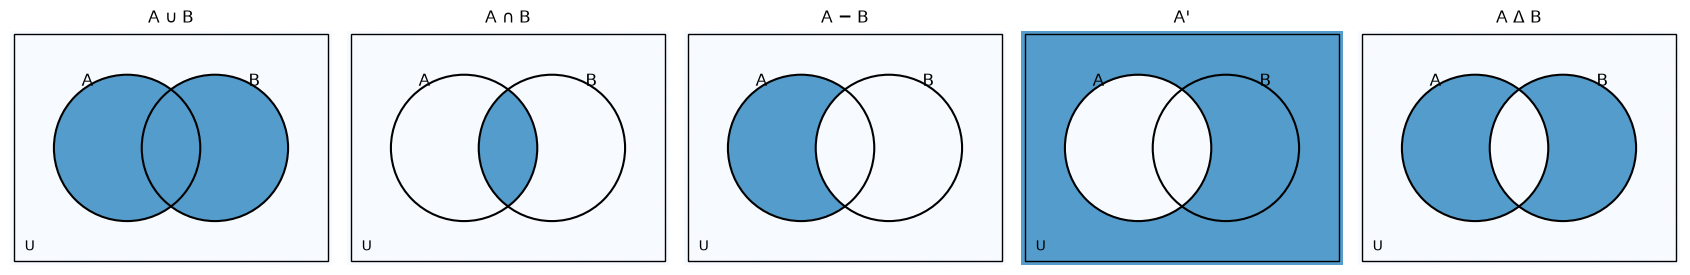

In [3]:
U = set(range(1, 11)); A = {n for n in U if n % 2 == 0}; B = {n for n in U if n % 3 == 0}
print("A ∪ B =", sorted(A | B)); print("A ∩ B =", sorted(A & B)); print("A − B =", sorted(A - B))
print("A'    =", sorted(U - A)); print("A Δ B =", sorted(A ^ B))

def venn(ax, shade, title):
    """Shade regions of a 2-set Venn diagram; shade(inA, inB) -> bool."""
    xs, ys = np.meshgrid(np.linspace(-2.2, 2.2, 400), np.linspace(-1.6, 1.6, 300))
    inA = (xs + 0.6)**2 + ys**2 < 1; inB = (xs - 0.6)**2 + ys**2 < 1
    ax.imshow(np.vectorize(shade)(inA, inB), extent=(-2.2, 2.2, -1.6, 1.6), origin="lower", cmap="Blues", vmin=0, vmax=1.6, alpha=0.9)
    for cx, lab in [(-0.6, "A"), (0.6, "B")]:
        ax.add_patch(Circle((cx, 0), 1, fill=False, lw=1.5)); ax.text(cx * 1.9, 0.85, lab, fontsize=12, ha="center")
    ax.add_patch(plt.Rectangle((-2.15, -1.55), 4.3, 3.1, fill=False, lw=1)); ax.text(-2.0, -1.4, "U")
    ax.set_title(title); ax.axis("off")

fig, axes = plt.subplots(1, 5, figsize=(17, 3))
for ax, (f, t) in zip(axes, [(lambda a, b: a or b, "A ∪ B"), (lambda a, b: a and b, "A ∩ B"), (lambda a, b: a and not b, "A − B"),
                             (lambda a, b: not a, "A'"), (lambda a, b: a != b, "A Δ B")]):
    venn(ax, f, t)
plt.tight_layout(); plt.show()

## 4. Laws of Set Algebra

| Law | Union form | Intersection form |
|-----|-----------|-------------------|
| Commutative | $A \cup B = B \cup A$ | $A \cap B = B \cap A$ |
| Associative | $(A \cup B) \cup C = A \cup (B \cup C)$ | $(A \cap B) \cap C = A \cap (B \cap C)$ |
| Distributive | $A \cup (B \cap C) = (A \cup B) \cap (A \cup C)$ | $A \cap (B \cup C) = (A \cap B) \cup (A \cap C)$ |
| Identity | $A \cup \varnothing = A$ | $A \cap U = A$ |
| Domination | $A \cup U = U$ | $A \cap \varnothing = \varnothing$ |
| Idempotent | $A \cup A = A$ | $A \cap A = A$ |
| Complement | $A \cup A' = U$ | $A \cap A' = \varnothing$ |
| **De Morgan** | $(A \cup B)' = A' \cap B'$ | $(A \cap B)' = A' \cup B'$ |
| Absorption | $A \cup (A \cap B) = A$ | $A \cap (A \cup B) = A$ |

Also: $(A')' = A$, $\;\varnothing' = U$, $\;U' = \varnothing$.

**De Morgan in words:** "not (A or B)" = "not A and not B"; "not (A and B)" = "not A or not B". The same laws appear in logic (Section 11) and in digital electronics (NAND/NOR gates).

### Proving a set identity (element method)
To show $A \cap (B \cup C) = (A \cap B) \cup (A \cap C)$: take $x \in$ LHS, show $x \in$ RHS; then the reverse. Each step uses the definitions of $\cap$ and $\cup$.

In [4]:
# Check every law on all combinations of subsets of a small universe (exhaustive brute force)
U = frozenset(range(4)); subsets = [frozenset(s) for s in powerset(U)]
comp = lambda S: U - S
laws = {
    "Distributive ∪": lambda A, B, C: A | (B & C) == (A | B) & (A | C),
    "Distributive ∩": lambda A, B, C: A & (B | C) == (A & B) | (A & C),
    "De Morgan ∪":    lambda A, B, C: comp(A | B) == comp(A) & comp(B),
    "De Morgan ∩":    lambda A, B, C: comp(A & B) == comp(A) | comp(B),
    "Absorption":     lambda A, B, C: A | (A & B) == A and A & (A | B) == A,
    "A − B = A ∩ B'": lambda A, B, C: A - B == A & comp(B),
}
for name, law in laws.items():
    ok = all(law(A, B, C) for A in subsets for B in subsets for C in subsets)
    print(f"{name:<16} holds for all {len(subsets)**3} triples: {ok}")

Distributive ∪   holds for all 4096 triples: True
Distributive ∩   holds for all 4096 triples: True
De Morgan ∪      holds for all 4096 triples: True
De Morgan ∩      holds for all 4096 triples: True
Absorption       holds for all 4096 triples: True
A − B = A ∩ B'   holds for all 4096 triples: True


## 5. Counting with Sets (Cardinality)

### Two sets
$$\boxed{n(A \cup B) = n(A) + n(B) - n(A \cap B)}$$
(Elements in both are counted twice, so subtract once.) Related:
- $n(A - B) = n(A) - n(A \cap B)$ ("only $A$")
- $n(A') = n(U) - n(A)$
- $n(\text{neither}) = n(U) - n(A \cup B)$
- $n(A \,\Delta\, B) = n(A) + n(B) - 2n(A \cap B)$ ("exactly one")

**Example.** Of 100 students, 60 study Maths, 50 Physics, 30 both. At least one: $60 + 50 - 30 = 80$; neither: 20; only Maths: 30.

### Three sets
$$n(A \cup B \cup C) = n(A) + n(B) + n(C) - n(A \cap B) - n(B \cap C) - n(C \cap A) + n(A \cap B \cap C)$$
- Exactly one: $\sum n(A) - 2\sum n(A \cap B) + 3\,n(A \cap B \cap C)$
- Exactly two: $\sum n(A \cap B) - 3\,n(A \cap B \cap C)$

**Example.** 100 students: M 50, P 45, C 40, M∩P 20, P∩C 15, M∩C 18, all three 10.
- At least one: $135 - 53 + 10 = 92$; none: 8.
- Exactly one: $135 - 106 + 30 = 59$; exactly two: $53 - 30 = 23$.

**Strategy for survey problems:** fill the Venn diagram **from the centre outwards** (all three first, then "exactly two" regions, then "only" regions).

This is the **inclusion–exclusion principle** from `combinatorics.ipynb`.

In [5]:
nM, nP, nC, nMP, nPC, nMC, nAll = 50, 45, 40, 20, 15, 18, 10
union = nM + nP + nC - nMP - nPC - nMC + nAll
only = [nM - nMP - nMC + nAll, nP - nMP - nPC + nAll, nC - nPC - nMC + nAll]
two = [nMP - nAll, nPC - nAll, nMC - nAll]
print("at least one:", union, "| none:", 100 - union)
print("only M, P, C:", only, "-> exactly one =", sum(only))
print("exactly two (MP, PC, MC):", two, "->", sum(two))
print("check regions add up:", sum(only) + sum(two) + nAll, "=", union)

at least one: 92 | none: 8
only M, P, C: [22, 20, 17] -> exactly one = 59
exactly two (MP, PC, MC): [10, 5, 8] -> 23
check regions add up: 92 = 92


# Part B — Relations and Functions

## 6. Cartesian Product

$$A \times B = \{(a, b) : a \in A,\ b \in B\}$$
the set of all **ordered pairs** (first from $A$, second from $B$).

- $n(A \times B) = n(A) \cdot n(B)$
- $A \times B \neq B \times A$ in general (order matters in pairs: $(1, 2) \neq (2, 1)$).
- $A \times \varnothing = \varnothing$.
- $\mathbb{R} \times \mathbb{R} = \mathbb{R}^2$ is the coordinate plane.
- Equal ordered pairs: $(a, b) = (c, d) \iff a = c$ and $b = d$.

**Example.** $A = \{1, 2\}$, $B = \{a, b, c\}$: $A \times B = \{(1,a), (1,b), (1,c), (2,a), (2,b), (2,c)\}$ — 6 pairs.

## 7. Relations

A **relation** $R$ from $A$ to $B$ is **any subset** of $A \times B$. We write $a\,R\,b$ when $(a, b) \in R$.

| Term | Meaning |
|------|---------|
| Domain | set of first elements that appear |
| Range | set of second elements that appear |
| Codomain | $B$ (the whole target set) |
| Inverse relation | $R^{-1} = \{(b, a) : (a, b) \in R\}$ |
| Relation **on** $A$ | a subset of $A \times A$ |

**Number of relations** from $A$ to $B$: each of the $mn$ pairs is in or out → $\boxed{2^{mn}}$. On a set with $n$ elements: $2^{n^2}$.

### Representations
- **Roster:** $R = \{(1, 2), (2, 3)\}$
- **Set-builder:** $R = \{(a, b) : b = a + 1\}$
- **Arrow diagram**
- **Matrix:** entry $(i, j)$ is 1 if $a_i R b_j$ (see the code below)

**Example.** On $A = \{1, 2, 3, 4, 6\}$, $R = \{(a, b) : a \text{ divides } b,\ a \neq b\}$
$= \{(1,2), (1,3), (1,4), (1,6), (2,4), (2,6), (3,6)\}$. Domain $\{1, 2, 3\}$, range $\{2, 3, 4, 6\}$.

In [6]:
A, B = {1, 2}, {"a", "b", "c"}
AxB = set(product(A, B)); print("A × B =", sorted(AxB), "->", len(AxB), "pairs")
print("relations from A to B: 2^6 =", 2**len(AxB))

S = [1, 2, 3, 4, 6]
R = {(a, b) for a in S for b in S if b % a == 0 and a != b}
print("R =", sorted(R)); print("domain", sorted({a for a, _ in R}), "| range", sorted({b for _, b in R}))
print("R⁻¹ =", sorted((b, a) for a, b in R))
M = np.array([[1 if (a, b) in R else 0 for b in S] for a in S])
print("relation matrix (rows a, cols b):\n", M)

A × B = [(1, 'a'), (1, 'b'), (1, 'c'), (2, 'a'), (2, 'b'), (2, 'c')] -> 6 pairs
relations from A to B: 2^6 = 64
R = [(1, 2), (1, 3), (1, 4), (1, 6), (2, 4), (2, 6), (3, 6)]
domain [1, 2, 3] | range [2, 3, 4, 6]
R⁻¹ = [(2, 1), (3, 1), (4, 1), (4, 2), (6, 1), (6, 2), (6, 3)]
relation matrix (rows a, cols b):
 [[0 1 1 1 1]
 [0 0 0 1 1]
 [0 0 0 0 1]
 [0 0 0 0 0]
 [0 0 0 0 0]]


## 8. Types of Relations

For a relation $R$ on a set $A$:

| Property | Definition | Matrix picture |
|----------|------------|----------------|
| **Reflexive** | $(a, a) \in R$ for **every** $a \in A$ | all diagonal entries 1 |
| **Symmetric** | $(a, b) \in R \Rightarrow (b, a) \in R$ | matrix is symmetric |
| **Antisymmetric** | $(a, b), (b, a) \in R \Rightarrow a = b$ | no pair of mirrored 1s off the diagonal |
| **Transitive** | $(a, b), (b, c) \in R \Rightarrow (a, c) \in R$ | |

Special relations: **empty** $\varnothing$, **universal** $A \times A$, **identity** $\{(a, a) : a \in A\}$.

### Examples
| Relation | Reflexive | Symmetric | Transitive |
|----------|-----------|-----------|------------|
| "$=$" on $\mathbb{R}$ | ✓ | ✓ | ✓ |
| "$\le$" on $\mathbb{R}$ | ✓ | ✗ (antisymmetric) | ✓ |
| "$<$" on $\mathbb{R}$ | ✗ | ✗ | ✓ |
| "divides" on $\mathbb{N}$ | ✓ | ✗ (antisymmetric) | ✓ |
| "is perpendicular to" (lines) | ✗ | ✓ | ✗ |
| "is parallel to" (lines, counting a line as parallel to itself) | ✓ | ✓ | ✓ |
| "is a sibling of" | ✗ | ✓ | ✗ (A–B–A) |
| $a\,R\,b \iff 3 \mid (a - b)$ on $\mathbb{Z}$ | ✓ | ✓ | ✓ |

### Showing a property fails
One **counterexample** is enough. $R = \{(a, b) : a \le b^2\}$ on $\mathbb{R}$:
- not reflexive: $\tfrac{1}{2} > \left(\tfrac{1}{2}\right)^2$
- not symmetric: $1 \le 2^2$ but $2 > 1^2$
- not transitive: $3 \le 2^2$ and $2 \le 1.5^2$, but $3 > 1.5^2$

### Watch out
- The empty relation on a non-empty set is **symmetric and transitive** (nothing to check) but **not reflexive**.
- "Symmetric" and "antisymmetric" are **not opposites**: the identity relation is both.

### Counting relations on a set with $n$ elements
| Kind | Count |
|------|-------|
| All relations | $2^{n^2}$ |
| Reflexive | $2^{n^2 - n}$ |
| Symmetric | $2^{n(n + 1)/2}$ |
| Reflexive and symmetric | $2^{n(n - 1)/2}$ |
| Equivalence relations | Bell number $B_n$: $1, 2, 5, 15, 52, \dots$ |

### Closures
The **transitive closure** adds the minimum pairs needed for transitivity. $\{(1,2), (2,3), (3,4)\}$ on $\{1, 2, 3, 4\}$ needs $(1,3), (2,4), (1,4)$.

In [7]:
def reflexive(R, S):     return all((a, a) in R for a in S)
def symmetric(R):        return all((b, a) in R for a, b in R)
def antisymmetric(R):    return all(a == b for a, b in R if (b, a) in R)
def transitive(R):       return all((a, d) in R for a, b in R for c, d in R if b == c)
def props(R, S):         return dict(reflexive=reflexive(R, S), symmetric=symmetric(R), antisymmetric=antisymmetric(R), transitive=transitive(R))

S = range(1, 7)
examples = {
    "a ≤ b":            {(a, b) for a in S for b in S if a <= b},
    "a < b":            {(a, b) for a in S for b in S if a < b},
    "a divides b":      {(a, b) for a in S for b in S if b % a == 0},
    "3 | (a − b)":      {(a, b) for a in S for b in S if (a - b) % 3 == 0},
    "|a − b| = 1":      {(a, b) for a in S for b in S if abs(a - b) == 1},
    "empty":            set(),
}
for name, R in examples.items():
    print(f"{name:<14}", props(R, S))

# Brute-force counts on a 3-element set (2^9 = 512 relations)
T = [0, 1, 2]; pairs = list(product(T, T))
allR = [{p for p, keep in zip(pairs, bits) if keep} for bits in product([0, 1], repeat=9)]
print("\nOn a 3-element set:")
print("  reflexive:", sum(reflexive(R, T) for R in allR), "= 2^6 =", 2**6)
print("  symmetric:", sum(symmetric(R) for R in allR), "= 2^6 =", 2**6)
print("  reflexive & symmetric:", sum(reflexive(R, T) and symmetric(R) for R in allR), "= 2^3 =", 2**3)
print("  equivalence relations:", sum(reflexive(R, T) and symmetric(R) and transitive(R) for R in allR), "(Bell number B3 = 5)")

def transitive_closure(R):
    R = set(R)
    while True:
        new = {(a, d) for a, b in R for c, d in R if b == c} - R
        if not new: return R
        R |= new
print("\ntransitive closure of {(1,2),(2,3),(3,4)}:", sorted(transitive_closure({(1, 2), (2, 3), (3, 4)})))

a ≤ b          {'reflexive': True, 'symmetric': False, 'antisymmetric': True, 'transitive': True}
a < b          {'reflexive': False, 'symmetric': False, 'antisymmetric': True, 'transitive': True}
a divides b    {'reflexive': True, 'symmetric': False, 'antisymmetric': True, 'transitive': True}
3 | (a − b)    {'reflexive': True, 'symmetric': True, 'antisymmetric': False, 'transitive': True}
|a − b| = 1    {'reflexive': False, 'symmetric': True, 'antisymmetric': False, 'transitive': False}
empty          {'reflexive': False, 'symmetric': True, 'antisymmetric': True, 'transitive': True}

On a 3-element set:
  reflexive: 64 = 2^6 = 64
  symmetric: 64 = 2^6 = 64
  reflexive & symmetric: 8 = 2^3 = 8
  equivalence relations: 5 (Bell number B3 = 5)

transitive closure of {(1,2),(2,3),(3,4)}: [(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]


## 9. Equivalence Relations and Partitions

A relation that is **reflexive, symmetric and transitive** is an **equivalence relation**. It captures "is the same as, in some respect".

### Equivalence classes
The **equivalence class** of $a$ is $[a] = \{x \in A : x\,R\,a\}$.
- Every element is in exactly one class.
- Two classes are either **identical or disjoint**.
- The classes form a **partition** of $A$: non-empty, pairwise disjoint subsets whose union is $A$.

Conversely, every partition defines an equivalence relation ("in the same block"). So equivalence relations on $A$ ↔ partitions of $A$.

**Example.** $a\,R\,b \iff 3 \mid (a - b)$ on $\mathbb{Z}$ (congruence modulo 3). Classes:
$[0] = \{\dots, -3, 0, 3, 6, \dots\}$, $[1] = \{\dots, -2, 1, 4, \dots\}$, $[2] = \{\dots, -1, 2, 5, \dots\}$.
This is the basis of **modular arithmetic**, used in cryptography, hashing and check digits.

**Example.** $R = \{(1,1), (2,2), (3,3), (1,2), (2,1)\}$ on $\{1, 2, 3\}$ is an equivalence relation with classes $\{1, 2\}$ and $\{3\}$.

**Proof pattern** ($a\,R\,b \iff a - b$ is even, on $\mathbb{Z}$):
- Reflexive: $a - a = 0$ is even.
- Symmetric: if $a - b = 2k$, then $b - a = 2(-k)$.
- Transitive: if $a - b = 2k$ and $b - c = 2l$, then $a - c = 2(k + l)$.
Classes: the even integers and the odd integers.

### Partial orders (for CS)
A relation that is **reflexive, antisymmetric and transitive** is a **partial order** ($\le$ on $\mathbb{R}$, "divides" on $\mathbb{N}$, $\subseteq$ on sets). Used for scheduling tasks with dependencies.

In [8]:
classes = {}
for n in range(-6, 10):
    classes.setdefault(n % 3, []).append(n)
for r, members in classes.items():
    print(f"[{r}] =", members)

[0] = [-6, -3, 0, 3, 6, 9]
[1] = [-5, -2, 1, 4, 7]
[2] = [-4, -1, 2, 5, 8]


## 10. Functions as Special Relations

A **function** $f : A \to B$ is a relation in which **every** element of $A$ is paired with **exactly one** element of $B$.
- $A$ = domain, $B$ = codomain, $\{f(a) : a \in A\}$ = **range** (image) $\subseteq B$.
- Vertical line test: a graph is a function if every vertical line meets it at most once.

(Functions in depth — graphs, limits, derivatives — are in your MIT 18.01 notes.)

### Types of functions
| Type | Meaning | Test |
|------|---------|------|
| **One-one (injective)** | different inputs → different outputs: $f(a_1) = f(a_2) \Rightarrow a_1 = a_2$ | horizontal line meets graph at most once |
| **Onto (surjective)** | every element of $B$ is hit: range $=$ codomain | |
| **Bijective** | both one-one and onto | invertible |

**Examples**
- $f(x) = 2x + 3$, $\mathbb{R} \to \mathbb{R}$: bijective, $f^{-1}(x) = \dfrac{x - 3}{2}$.
- $f(x) = x^2$, $\mathbb{R} \to \mathbb{R}$: neither ($f(-1) = f(1)$; $-1$ is never hit).
- $f(x) = x^2$, $[0, \infty) \to [0, \infty)$: bijective, $f^{-1}(x) = \sqrt{x}$. **Changing the domain or codomain changes the type.**

### Counting functions ($n(A) = m$, $n(B) = n$)
| Kind | Count |
|------|-------|
| All functions | $n^m$ |
| One-one (needs $m \le n$) | ${}^nP_m = \dfrac{n!}{(n - m)!}$ |
| Onto (needs $m \ge n$) | $\sum_{k=0}^{n}(-1)^k\binom{n}{k}(n - k)^m$ |
| Bijections (needs $m = n$) | $n!$ |

$A$ with 3 elements, $B$ with 4: $4^3 = 64$ functions, ${}^4P_3 = 24$ one-one, 0 onto.
Onto functions from a 4-element set to a 3-element set: $3^4 - 3 \cdot 2^4 + 3 = 36$.

### Composition and inverse
- $(g \circ f)(x) = g(f(x))$ — apply $f$ first.
- In general $g \circ f \neq f \circ g$: with $f(x) = x^2$, $g(x) = x + 1$: $\;(f \circ g)(x) = (x + 1)^2$, $\;(g \circ f)(x) = x^2 + 1$.
- $f$ has an inverse $\iff$ $f$ is bijective; then $f^{-1}(f(x)) = x$ and $f(f^{-1}(y)) = y$.
- $(g \circ f)^{-1} = f^{-1} \circ g^{-1}$ (undo in reverse order — like taking off socks and shoes).

In [9]:
A, B = [1, 2, 3], ["a", "b", "c", "d"]
funcs = list(product(B, repeat=len(A)))           # each function = tuple of images of 1, 2, 3
print("functions A→B:", len(funcs), "| one-one:", sum(len(set(f)) == len(A) for f in funcs),
      "| onto:", sum(set(f) == set(B) for f in funcs))
onto = sum(set(f) == {0, 1, 2} for f in product(range(3), repeat=4))
print("onto functions from 4-element set to 3-element set:", onto)

X = sp.symbols("x")
f, g = X**2, X + 1
print("f∘g =", sp.expand(f.subs(X, g)), "| g∘f =", sp.expand(g.subs(X, f)))
yv = sp.symbols("y"); print("inverse of 2x+3:", sp.solve(sp.Eq(2*X + 3, yv), X)[0].subs(yv, X))

functions A→B: 64 | one-one: 24 | onto: 0
onto functions from 4-element set to 3-element set: 36
f∘g = x**2 + 2*x + 1 | g∘f = x**2 + 1
inverse of 2x+3: x/2 - 3/2


# Part C — Logic and Induction

## 11. Mathematical Reasoning (Logic Basics)

A **statement** (proposition) is a sentence that is either true or false, not both. "7 is prime" is a statement; "close the door" is not.

### Connectives
| Connective | Symbol | True when |
|------------|--------|-----------|
| NOT $p$ | $\neg p$ | $p$ is false |
| $p$ AND $q$ | $p \wedge q$ | both true |
| $p$ OR $q$ | $p \vee q$ | at least one true |
| IF $p$ THEN $q$ | $p \Rightarrow q$ | false **only** when $p$ true and $q$ false |
| $p$ IF AND ONLY IF $q$ | $p \Leftrightarrow q$ | same truth value |

### Implication and its relatives
For $p \Rightarrow q$ ("if it rains, the ground is wet"):

| Name | Form | Equivalent to the original? |
|------|------|-----------------------------|
| Converse | $q \Rightarrow p$ | **No** |
| Inverse | $\neg p \Rightarrow \neg q$ | **No** |
| **Contrapositive** | $\neg q \Rightarrow \neg p$ | **Yes** |

So to prove "if $n^2$ is even then $n$ is even", you may prove the contrapositive "if $n$ is odd then $n^2$ is odd".

### Quantifiers
- $\forall$ "for all", $\exists$ "there exists".
- Negations: $\neg(\forall x,\ P(x)) \equiv \exists x,\ \neg P(x)$ and $\neg(\exists x,\ P(x)) \equiv \forall x,\ \neg P(x)$.
- To disprove "for all", one **counterexample** is enough. To prove it, you need an argument for **every** case — which is where induction comes in for statements about all $n \in \mathbb{N}$.

### Proof methods
| Method | Idea |
|--------|------|
| Direct | assume $p$, deduce $q$ |
| Contrapositive | assume $\neg q$, deduce $\neg p$ |
| Contradiction | assume the statement is false, reach an impossibility ($\sqrt{2}$ is irrational) |
| Counterexample | disprove a universal claim |
| **Induction** | prove for all $n \ge n_0$ (next sections) |

In [10]:
print(f"{'p':<6}{'q':<6}{'p⇒q':<7}{'q⇒p':<7}{'¬q⇒¬p':<8}{'¬(p∧q)':<9}{'¬p∨¬q'}")
imp = lambda a, b: (not a) or b
for p_, q_ in product([True, False], repeat=2):
    print(f"{str(p_):<6}{str(q_):<6}{str(imp(p_, q_)):<7}{str(imp(q_, p_)):<7}{str(imp(not q_, not p_)):<8}{str(not (p_ and q_)):<9}{(not p_) or (not q_)}")
print("\np⇒q column equals ¬q⇒¬p (contrapositive), not q⇒p (converse); De Morgan columns match.")

p     q     p⇒q    q⇒p    ¬q⇒¬p   ¬(p∧q)   ¬p∨¬q
True  True  True   True   True    False    False
True  False False  True   False   True     True
False True  True   False  True    True     True
False False True   True   True    True     True

p⇒q column equals ¬q⇒¬p (contrapositive), not q⇒p (converse); De Morgan columns match.


## 12. Principle of Mathematical Induction

To prove a statement $P(n)$ for **all** natural numbers $n \ge n_0$:

1. **Base case:** prove $P(n_0)$ is true (usually $n_0 = 1$).
2. **Inductive step:** assume $P(k)$ is true for some arbitrary $k \ge n_0$ (the **inductive hypothesis**), and use it to prove $P(k + 1)$.

Then $P(n)$ is true for all $n \ge n_0$.

**Why it works — the domino picture:** the base case knocks over the first domino; the inductive step guarantees each falling domino knocks over the next. So all of them fall.

### Writing a clean induction proof
```
Let P(n): <the statement>.
Base case (n = 1): LHS = ..., RHS = ..., so P(1) is true.
Inductive step: Assume P(k) is true, i.e. <write P(k)>.
  We must show P(k+1): <write P(k+1)>.
  LHS of P(k+1) = <split off the last term> = <use P(k)> = ... = RHS of P(k+1).
Hence by the principle of mathematical induction, P(n) is true for all n ≥ 1.
```
**Always write $P(k + 1)$ explicitly before proving it** — it tells you exactly what target to aim for.

### Typical types
| Type | Key move in the inductive step |
|------|--------------------------------|
| Summation $\sum_{i=1}^{n}$ | $S(k + 1) = S(k) + (\text{term } k + 1)$, then simplify |
| Divisibility | write the $(k + 1)$ expression as (multiple of the $k$ expression) + (obvious multiple) |
| Inequality | use $P(k)$, then a simple bound to reach the target |
| Recurrences / sequences | use the recurrence to go from $k$ to $k + 1$ |

## 13. Induction: Worked Examples

### Example 1 (sum). $1 + 2 + \dots + n = \dfrac{n(n + 1)}{2}$
- **Base:** $n = 1$: $1 = \tfrac{1 \cdot 2}{2}$ ✓
- **Step:** assume $1 + \dots + k = \tfrac{k(k + 1)}{2}$. Then
$$1 + \dots + k + (k + 1) = \frac{k(k + 1)}{2} + (k + 1) = \frac{(k + 1)(k + 2)}{2}$$
which is $P(k + 1)$. ∎

### Example 2 (sum of squares). $1^2 + 2^2 + \dots + n^2 = \dfrac{n(n + 1)(2n + 1)}{6}$
- **Base:** $1 = \tfrac{1 \cdot 2 \cdot 3}{6}$ ✓
- **Step:** $\dfrac{k(k + 1)(2k + 1)}{6} + (k + 1)^2 = \dfrac{(k + 1)[k(2k + 1) + 6(k + 1)]}{6} = \dfrac{(k + 1)(2k^2 + 7k + 6)}{6} = \dfrac{(k + 1)(k + 2)(2k + 3)}{6}$ ∎

### Example 3 (odd numbers). $1 + 3 + \dots + (2n - 1) = n^2$
Step: $k^2 + (2k + 1) = (k + 1)^2$ ∎

### Example 4 (divisibility). $8 \mid 3^{2n} - 1$, i.e. $9^n - 1$ is divisible by 8
- **Base:** $9 - 1 = 8$ ✓
- **Step:** assume $9^k - 1 = 8m$. Then
$$9^{k+1} - 1 = 9 \cdot 9^k - 1 = 9(9^k - 1) + 8 = 9(8m) + 8 = 8(9m + 1)$$ ∎
**Trick:** "add and subtract" to expose the $P(k)$ expression.

### Example 5 (divisibility). $4 \mid 7^n - 3^n$
Step: $7^{k+1} - 3^{k+1} = 7(7^k - 3^k) + 7 \cdot 3^k - 3 \cdot 3^k = 7(7^k - 3^k) + 4 \cdot 3^k$ ∎

### Example 6 (inequality, later start). $n! > 2^n$ for $n \ge 4$
- **Base:** $4! = 24 > 16 = 2^4$ ✓ (it is **false** for $n = 1, 2, 3$, so the base must be $n = 4$)
- **Step:** $(k + 1)! = (k + 1) \cdot k! > (k + 1) \cdot 2^k > 2 \cdot 2^k = 2^{k+1}$, since $k + 1 > 2$ ∎

### Example 7 (Bernoulli's inequality). $(1 + x)^n \ge 1 + nx$ for $x \ge -1$, $n \ge 1$
Step: $(1 + x)^{k+1} = (1 + x)^k(1 + x) \ge (1 + kx)(1 + x) = 1 + (k + 1)x + kx^2 \ge 1 + (k + 1)x$
(using $1 + x \ge 0$ to keep the inequality direction) ∎

### Example 8 (recurrence). If $a_1 = 1$ and $a_{n+1} = 2a_n + 1$, then $a_n = 2^n - 1$
Step: $a_{k+1} = 2(2^k - 1) + 1 = 2^{k+1} - 1$ ∎

In [11]:
# 1) Numerical check for many n; 2) SymPy check that the inductive step closes
kk = sp.symbols("k", integer=True, positive=True)
claims = {
    "Σ i = n(n+1)/2":            (lambda n: sum(range(1, n + 1)),            lambda n: n*(n + 1)/2),
    "Σ i² = n(n+1)(2n+1)/6":     (lambda n: sum(i*i for i in range(1, n + 1)), lambda n: n*(n + 1)*(2*n + 1)/6),
    "Σ (2i−1) = n²":             (lambda n: sum(2*i - 1 for i in range(1, n + 1)), lambda n: n**2),
}
for name, (lhs, rhs) in claims.items():
    numeric = all(lhs(n) == rhs(n) for n in range(1, 101))
    print(f"{name:<24} true for n = 1..100: {numeric}")

# Inductive step: P(k) closed form + (k+1)-th term must equal P(k+1) closed form
steps = {
    "Σ i":      (kk*(kk + 1)/2,               kk + 1),
    "Σ i²":     (kk*(kk + 1)*(2*kk + 1)/6,    (kk + 1)**2),
    "Σ (2i−1)": (kk**2,                       2*kk + 1),
}
for name, (S_k, term) in steps.items():
    print(f"step for {name:<9}: S(k) + term − S(k+1) =", sp.simplify(S_k + term - S_k.subs(kk, kk + 1)))

print("divisibility step: 9^(k+1) − 1 − [9(9^k − 1) + 8] =", sp.simplify(9**(kk + 1) - 1 - (9*(9**kk - 1) + 8)))
print("8 | 9^n − 1 for n = 1..50:", all((9**n - 1) % 8 == 0 for n in range(1, 51)))
print("4 | 7^n − 3^n for n = 1..50:", all((7**n - 3**n) % 4 == 0 for n in range(1, 51)))
print("n! > 2^n holds for n =", [n for n in range(1, 12) if math.factorial(n) > 2**n], "(fails for 1, 2, 3)")
a = 1; ok = True
for n in range(1, 30):
    ok &= a == 2**n - 1; a = 2*a + 1
print("a_n = 2^n − 1 for n = 1..29:", ok)

Σ i = n(n+1)/2           true for n = 1..100: True
Σ i² = n(n+1)(2n+1)/6    true for n = 1..100: True
Σ (2i−1) = n²            true for n = 1..100: True
step for Σ i      : S(k) + term − S(k+1) = 0
step for Σ i²     : S(k) + term − S(k+1) = 0
step for Σ (2i−1) : S(k) + term − S(k+1) = 0
divisibility step: 9^(k+1) − 1 − [9(9^k − 1) + 8] = 0
8 | 9^n − 1 for n = 1..50: True
4 | 7^n − 3^n for n = 1..50: True
n! > 2^n holds for n = [4, 5, 6, 7, 8, 9, 10, 11] (fails for 1, 2, 3)
a_n = 2^n − 1 for n = 1..29: True


## 14. Strong Induction and Common Pitfalls

### Strong induction
In the inductive step, assume $P(n_0), P(n_0 + 1), \dots, P(k)$ are **all** true, then prove $P(k + 1)$. Use it when $P(k + 1)$ depends on cases further back than $P(k)$.

**Example (prime factorisation).** Every integer $n \ge 2$ is a product of primes.
If $k + 1$ is prime, done. Otherwise $k + 1 = ab$ with $2 \le a, b \le k$; by the (strong) hypothesis both $a$ and $b$ are products of primes, so $k + 1$ is too. ∎

**Example (stamps).** Every amount $n \ge 12$ can be paid with 4- and 5-unit stamps.
Bases: $12 = 4+4+4$, $13 = 4+4+5$, $14 = 4+5+5$, $15 = 5+5+5$. Step: for $k + 1 \ge 16$, pay $k - 3$ (true by hypothesis, since $k - 3 \ge 12$) and add one 4-unit stamp. ∎

**Example (Fibonacci bound).** $F_n < 2^n$: $F_{k+1} = F_k + F_{k-1} < 2^k + 2^{k-1} < 2^{k+1}$ — needs **two** previous cases (two base cases too).

### Pitfalls
| Pitfall | Example |
|---------|---------|
| **Skipping the base case** | "$n = n + 1$": if $k = k + 1$ then $k + 1 = k + 2$ — the step "works", but the statement is never true. |
| **Step that fails for one value of $k$** | "All horses are the same colour": the step from $k$ to $k + 1$ uses two overlapping groups of $k$ horses, which don't overlap when $k = 1$. The proof breaks going from 1 to 2. |
| Assuming what you want to prove | Assume $P(k)$, not $P(k + 1)$. |
| Checking a few cases and calling it a proof | $n^2 + n + 41$ is prime for $n = 0, \dots, 39$ but not for $n = 40$ ($40^2 + 40 + 41 = 41^2$). |
| Wrong base when the claim starts later | $n! > 2^n$ needs base $n = 4$. |

In [12]:
def euler_poly(n): return n*n + n + 41
first_composite = next(n for n in range(100) if not sp.isprime(euler_poly(n)))
print("n² + n + 41 is prime for n = 0 ..", first_composite - 1, "; at n =", first_composite, "it is", euler_poly(first_composite), "=", sp.factorint(euler_poly(first_composite)))
print("Stamps (4 and 5) can make:", [n for n in range(1, 30) if any(4*a + 5*b == n for a in range(10) for b in range(10))])
fib = [1, 1]
for _ in range(40): fib.append(fib[-1] + fib[-2])
print("F_n < 2^n for n = 1..42:", all(fib[i] < 2**(i + 1) for i in range(len(fib))))

n² + n + 41 is prime for n = 0 .. 39 ; at n = 40 it is 1681 = {41: 2}
Stamps (4 and 5) can make: [4, 5, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
F_n < 2^n for n = 1..42: True


## 15. Common Mistakes

| Mistake | Correct |
|---------|---------|
| $\{0\} = \varnothing$ | $\{0\}$ has one element; $\varnothing$ has none |
| $\varnothing \in A$ for every $A$ | $\varnothing \subseteq A$ always, but $\varnothing \in A$ only if it is listed as an element |
| Confusing $\in$ with $\subseteq$ | $2 \in \{1, 2\}$; $\{2\} \subseteq \{1, 2\}$ |
| $n(A \cup B) = n(A) + n(B)$ | Subtract $n(A \cap B)$ unless the sets are disjoint |
| $(A \cup B)' = A' \cup B'$ | De Morgan: $(A \cup B)' = A' \cap B'$ |
| $A \times B = B \times A$ | Ordered pairs: generally different |
| "Symmetric" and "antisymmetric" are opposites | A relation can be both (identity) or neither |
| Claiming reflexive after checking only the pairs that appear | Need $(a, a)$ for **every** $a \in A$ |
| Calling $x^2$ "one-one" without stating the domain | The answer depends on domain and codomain |
| Converse treated as equivalent to the implication | Only the **contrapositive** is equivalent |
| Induction without a base case | Both steps are required |
| Proving $P(k + 1)$ without using $P(k)$ | If $P(k)$ isn't used, it isn't induction (and probably isn't a proof) |
| Wrong starting value for $n$ | Check where the statement first becomes true |

## 16. Formula Sheet

| Item | Formula |
|------|---------|
| Power set | $n(\mathcal{P}(A)) = 2^{n(A)}$ |
| Union (2 sets) | $n(A \cup B) = n(A) + n(B) - n(A \cap B)$ |
| Union (3 sets) | $\sum n(A) - \sum n(A \cap B) + n(A \cap B \cap C)$ |
| Only $A$ | $n(A) - n(A \cap B)$ |
| Exactly one of two | $n(A) + n(B) - 2n(A \cap B)$ |
| De Morgan | $(A \cup B)' = A' \cap B'$, $\;(A \cap B)' = A' \cup B'$ |
| Difference | $A - B = A \cap B'$ |
| Cartesian product | $n(A \times B) = n(A)\,n(B)$ |
| Relations $A \to B$ | $2^{mn}$ |
| On $n$ elements: all / reflexive / symmetric | $2^{n^2}$ / $2^{n^2 - n}$ / $2^{n(n+1)/2}$ |
| Equivalence relation | reflexive + symmetric + transitive ↔ partition |
| Partial order | reflexive + antisymmetric + transitive |
| Functions $A \to B$ ($m \to n$) | all $n^m$; one-one ${}^nP_m$; onto $\sum_{k}(-1)^k\binom{n}{k}(n - k)^m$ |
| Composition / inverse | $(g \circ f)(x) = g(f(x))$; $(g \circ f)^{-1} = f^{-1} \circ g^{-1}$ |
| Contrapositive | $p \Rightarrow q \;\equiv\; \neg q \Rightarrow \neg p$ |
| Negating quantifiers | $\neg\forall \equiv \exists\neg$, $\;\neg\exists \equiv \forall\neg$ |
| Induction | $P(n_0)$ and $[P(k) \Rightarrow P(k + 1)]$ $\Rightarrow$ $P(n)$ for all $n \ge n_0$ |
| Standard sums | $\sum i = \tfrac{n(n+1)}{2}$, $\;\sum i^2 = \tfrac{n(n+1)(2n+1)}{6}$, $\;\sum(2i - 1) = n^2$ |

## 17. Practice Problems (with Answers)

### Level 1 — Sets
1. Write $\{x : x \text{ is a prime less than } 15\}$ in roster form.
2. How many subsets and proper subsets does $\{a, b, c, d\}$ have?
3. $U = \{1, \dots, 9\}$, $A = \{1, 2, 3, 4\}$, $B = \{3, 4, 5, 6\}$. Find $A \cup B$, $A \cap B$, $A - B$, $(A \cup B)'$.
4. If $n(A) = 25$, $n(B) = 18$, $n(A \cup B) = 35$, find $n(A \cap B)$.
5. In a class of 60, 35 like tea, 30 like coffee and 10 like neither. How many like both?
6. How many integers from 1 to 100 are divisible by 2, 3 or 5?

### Level 2 — Relations and functions
7. $A = \{1, 2\}$, $B = \{3, 4, 5\}$. Find $n(A \times B)$ and the number of relations from $A$ to $B$.
8. Is $R = \{(1,1), (2,2), (1,2)\}$ on $\{1, 2\}$ reflexive, symmetric, transitive?
9. Show $a\,R\,b \iff a - b$ is even is an equivalence relation on $\mathbb{Z}$, and find its classes.
10. Find the smallest transitive relation containing $\{(1,2), (2,3), (3,4)\}$ on $\{1, 2, 3, 4\}$.
11. Show $R = \{(a, b) : a \le b^2\}$ on $\mathbb{R}$ is neither reflexive, symmetric nor transitive.
12. How many reflexive relations are there on a set with 4 elements?
13. How many one-one functions are there from $\{1, 2, 3\}$ to $\{a, b, c, d, e\}$?
14. How many onto functions are there from a 4-element set to a 3-element set?
15. Show $f(x) = 3x - 4$ on $\mathbb{R}$ is bijective and find $f^{-1}$.
16. For $f(x) = x^2 + 1$ and $g(x) = 2x - 1$, find $f \circ g$ and $g \circ f$.

### Level 3 — Induction
17. Prove $1 + 2 + \dots + n = \dfrac{n(n + 1)}{2}$.
18. Prove $1^2 + 2^2 + \dots + n^2 = \dfrac{n(n + 1)(2n + 1)}{6}$.
19. Prove $7^n - 3^n$ is divisible by 4 for all $n \ge 1$.
20. Prove $2^n > n^2$ for all $n \ge 5$.

<details>
<summary><strong>Answers</strong> (click to expand)</summary>

1. $\{2, 3, 5, 7, 11, 13\}$
2. $2^4 = 16$ subsets, 15 proper subsets
3. $\{1, \dots, 6\}$; $\{3, 4\}$; $\{1, 2\}$; $\{7, 8, 9\}$
4. $25 + 18 - 35 = 8$
5. $50 = 35 + 30 - x \Rightarrow x = 15$
6. $50 + 33 + 20 - 16 - 10 - 6 + 3 = 74$
7. $6$; $2^6 = 64$
8. Reflexive ✓, symmetric ✗ ($(1,2)$ but not $(2,1)$), transitive ✓
9. Proof in Section 9; classes: even integers, odd integers
10. Add $(1,3), (2,4), (1,4)$
11. Counterexamples in Section 8: $\left(\tfrac{1}{2}, \tfrac{1}{2}\right)$; $(1, 2)$; $(3, 2), (2, 1.5)$
12. $2^{16 - 4} = 4096$
13. ${}^5P_3 = 60$
14. $3^4 - 3 \cdot 2^4 + 3 = 36$
15. One-one: $3a - 4 = 3b - 4 \Rightarrow a = b$. Onto: $y = 3x - 4$ has solution $x = \tfrac{y + 4}{3}$. $f^{-1}(x) = \tfrac{x + 4}{3}$
16. $f \circ g = (2x - 1)^2 + 1 = 4x^2 - 4x + 2$; $\;g \circ f = 2x^2 + 1$
17. Section 13, Example 1
18. Section 13, Example 2
19. $7^{k+1} - 3^{k+1} = 7(7^k - 3^k) + 4 \cdot 3^k$
20. Base $32 > 25$. Step: $2^{k+1} = 2 \cdot 2^k > 2k^2 \ge (k + 1)^2$, since $k^2 \ge 2k + 1$ for $k \ge 3$

</details>

In [13]:
# Check the practice answers
print(" 1.", sorted(n for n in range(2, 15) if sp.isprime(n)))
print(" 2.", 2**4, 2**4 - 1)
U = set(range(1, 10)); A = {1, 2, 3, 4}; B = {3, 4, 5, 6}
print(" 3.", sorted(A | B), sorted(A & B), sorted(A - B), sorted(U - (A | B)))
print(" 4.", 25 + 18 - 35)
print(" 5.", 35 + 30 - (60 - 10))
print(" 6.", sum(1 for n in range(1, 101) if n % 2 == 0 or n % 3 == 0 or n % 5 == 0))
print(" 7.", 2*3, 2**(2*3))
R = {(1, 1), (2, 2), (1, 2)}; print(" 8.", props(R, [1, 2]))
R = {(a, b) for a in range(-5, 6) for b in range(-5, 6) if (a - b) % 2 == 0}
print(" 9.", props(R, range(-5, 6)))
print("10.", sorted(transitive_closure({(1, 2), (2, 3), (3, 4)}) - {(1, 2), (2, 3), (3, 4)}))
le = lambda a, b: a <= b**2
print("11.", "reflexive fails at 1/2:", not le(0.5, 0.5), "| symmetric fails (1,2):", le(1, 2) and not le(2, 1),
      "| transitive fails (3,2),(2,1.5):", le(3, 2) and le(2, 1.5) and not le(3, 1.5))
T = range(4); pairs4 = list(product(T, T))
print("12.", sum(1 for bits in product([0, 1], repeat=16) if all(bits[pairs4.index((a, a))] for a in T)))
print("13.", sum(1 for f in product("abcde", repeat=3) if len(set(f)) == 3))
print("14.", sum(1 for f in product(range(3), repeat=4) if set(f) == {0, 1, 2}))
X = sp.symbols("x"); yv = sp.symbols("y")
print("15.", sp.solve(sp.Eq(3*X - 4, yv), X)[0].subs(yv, X))
print("16.", sp.expand((X**2 + 1).subs(X, 2*X - 1)), "|", sp.expand((2*X - 1).subs(X, X**2 + 1)))
print("17.", sp.simplify(kk*(kk + 1)/2 + (kk + 1) - (kk + 1)*(kk + 2)/2) == 0)
print("18.", sp.simplify(kk*(kk + 1)*(2*kk + 1)/6 + (kk + 1)**2 - (kk + 1)*(kk + 2)*(2*kk + 3)/6) == 0)
print("19.", sp.simplify(7**(kk + 1) - 3**(kk + 1) - (7*(7**kk - 3**kk) + 4*3**kk)) == 0)
print("20.", [n for n in range(1, 15) if 2**n > n**2], "(fails only for n = 2, 3, 4 — so the claim needs n ≥ 5)")

 1. [2, 3, 5, 7, 11, 13]
 2. 16 15
 3. [1, 2, 3, 4, 5, 6] [3, 4] [1, 2] [7, 8, 9]
 4. 8
 5. 15
 6. 74
 7. 6 64
 8. {'reflexive': True, 'symmetric': False, 'antisymmetric': True, 'transitive': True}
 9. {'reflexive': True, 'symmetric': True, 'antisymmetric': False, 'transitive': True}
10. [(1, 3), (1, 4), (2, 4)]
11. reflexive fails at 1/2: True | symmetric fails (1,2): True | transitive fails (3,2),(2,1.5): True
12. 4096
13. 60
14. 36
15. x/3 + 4/3
16. 4*x**2 - 4*x + 2 | 2*x**2 + 1
17. True
18. True
19. True
20. [1, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14] (fails only for n = 2, 3, 4 — so the claim needs n ≥ 5)
